In [12]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [13]:
plt.style.use("default")
plt.rcParams["figure.figsize"] = (7 , 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.20
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["legend.fontsize"] = 10
X , y = make_moons(n_samples = 300 , noise = 0.22 , random_state = 42)
X_train , X_test , y_train , y_test = train_test_split(
    X , y , test_size = 0.25 , stratify = y , random_state = 42
)
model_simple = LogisticRegression(max_iter = 2000)
_ = model_simple.fit(X_train , y_train)
model_flexible = Pipeline([
    ("poly" , PolynomialFeatures(degree = 3 , include_bias = False)) ,
    ("logreg" , LogisticRegression(max_iter = 2000))
])
_ = model_flexible.fit(X_train , y_train)
simple_train_acc = accuracy_score(y_train , model_simple.predict(X_train))
simple_test_acc  = accuracy_score(y_test , model_simple.predict(X_test))
flex_train_acc = accuracy_score(y_train , model_flexible.predict(X_train))
flex_test_acc  = accuracy_score(y_test , model_flexible.predict(X_test))
print("Simple logistic regression")
print(f"Train accuracy: {simple_train_acc:.3f}")
print(f"Test accuracy: {simple_test_acc:.3f}")
print("\nFlexible polynomial logistic model")
print(f"Train accuracy: {flex_train_acc:.3f}")
print(f"Test accuracy: {flex_test_acc:.3f}")

Simple logistic regression
Train accuracy: 0.871
Test accuracy: 0.827

Flexible polynomial logistic model
Train accuracy: 0.916
Test accuracy: 0.880


In [14]:
def plot_decision_boundary(model , X , y , title):
    x_min , x_max = X[ : , 0].min() - 0.5 , X[ : , 0].max() + 0.5
    y_min , y_max = X[ : , 1].min() - 0.5 , X[ : , 1].max() + 0.5
    xx , yy = np.meshgrid(
        np.linspace(x_min , x_max , 400) , np.linspace(y_min , y_max , 400)
    )
    grid = np.c_[xx.ravel() , yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)
    fig , ax = plt.subplots()
    ax.contourf(xx , yy , Z , alpha = 0.15 , cmap = plt.cm.Pastel1)
    ax.contour(xx , yy , Z , levels = [0.5] , colors = "#6A1B9A" , linewidths = 2.5)
    ax.scatter(X[y == 0 , 0] , X[y == 0 , 1] , s = 60 , alpha = 0.80 ,
               color = "#4C78A8" , label = "Class 0")
    ax.scatter(X[y == 1 , 0] , X[y == 1 , 1] , s = 60 , alpha = 0.80 ,
               color = "#F58518" , label = "Class 1")
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.legend()
    fig.tight_layout()
    plt.show()

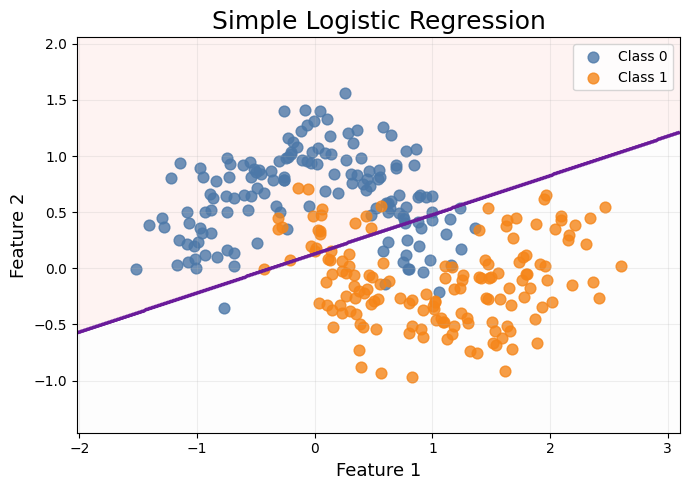

In [15]:
plot_decision_boundary(model_simple , X , y , "Simple Logistic Regression")

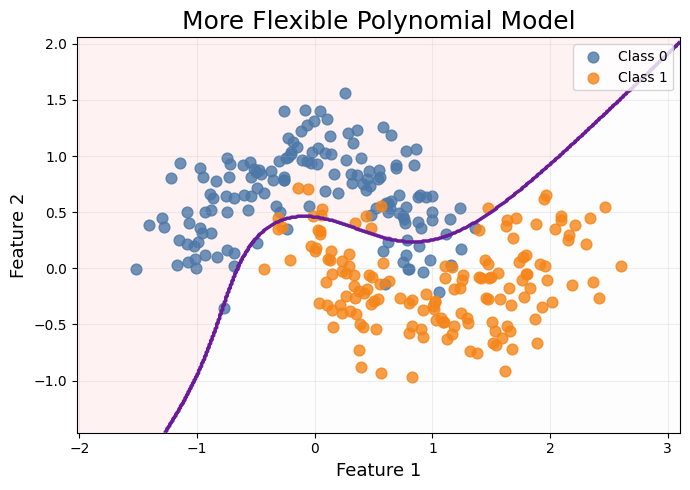

In [16]:
plot_decision_boundary(model_flexible , X , y , "More Flexible Polynomial Model")

<BarContainer object of 2 artists>

<BarContainer object of 2 artists>

[Text(0, 0, 'Simple'), Text(1, 0, 'Flexible')]

(0.75, 1.0)

Text(0, 0.5, 'Accuracy')

Text(0.5, 1.0, 'Model Comparison: Train vs Test Performance')

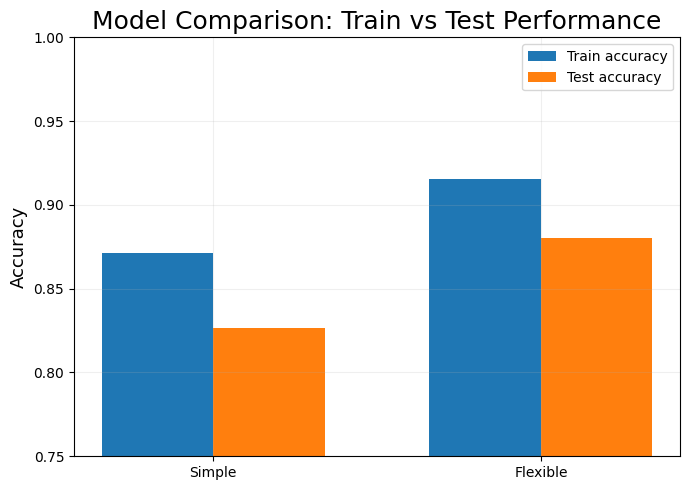

In [17]:
models = ["Simple" , "Flexible"]
train_scores = [simple_train_acc , flex_train_acc]
test_scores = [simple_test_acc , flex_test_acc]
x = np.arange(len(models))
width = 0.34
fig , ax = plt.subplots()
ax.bar(x - width / 2 , train_scores , width , label = "Train accuracy")
ax.bar(x + width / 2 , test_scores , width , label = "Test accuracy")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0.75 , 1.00)
ax.set_ylabel("Accuracy")
ax.set_title("Model Comparison: Train vs Test Performance")
ax.legend()
fig.tight_layout()
plt.show()

In [18]:
print("=" * 42)
print("================ Summary =================")
print("=" * 42)
print("The flexible model captures the curved structure better.")
print("But model selection is not about complexity alone.")
print("For prediction, compare models using unseen data.")
print("For inference, simpler and more interpretable models may be preferred.")


================ Summary =================
The flexible model captures the curved structure better.
But model selection is not about complexity alone.
For prediction, compare models using unseen data.
For inference, simpler and more interpretable models may be preferred.
